# Projekt 01 (basic): kNN von Hand — und der Bias-Variance-Tradeoff zum Anfassen

**Ziel:** Du baust k-Nearest-Neighbors **komplett selbst** (Distanz, Nachbarn,
Mehrheitsvotum), vergleichst mit scikit-learn und machst dann die zwei wichtigsten
Lektionen des Moduls **sichtbar**:

1. Warum Skalierung bei Distanzverfahren ueber Erfolg und Misserfolg entscheidet
   (hier: 78 % vs. 96 % Accuracy!),
2. wie der Hyperparameter $k$ den Bogen von Overfitting zu Underfitting spannt.

**Daten: echt** — unsere Pinguine aus Modul 02 (`seaborn.load_dataset`), diesmal
als Klassifikationsaufgabe: **Art bestimmen aus Schnabellaenge und Koerpermasse.**
Zwei Features mit bewusst extrem verschiedenen Skalen (Millimeter vs. Gramm!) —
das ist Teil der Didaktik.

**Bezug zum Skript:** Abschnitte 1.2 (kNN), 1.3 (Bias/Variance), 1.4 (Train/Test).

## 1. Daten und Split

Training: 239, Test: 103


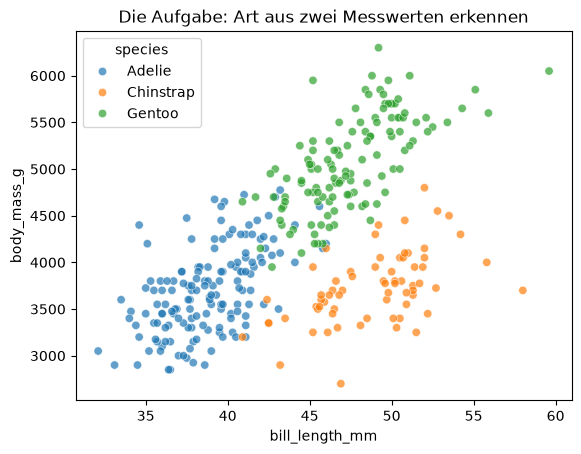

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split

df = sns.load_dataset("penguins").dropna(subset=["bill_length_mm", "body_mass_g", "species"])
X = df[["bill_length_mm", "body_mass_g"]].values
y = df["species"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Training: {len(X_train)}, Test: {len(X_test)}")

sns.scatterplot(data=df, x="bill_length_mm", y="body_mass_g", hue="species", alpha=0.7)
plt.title("Die Aufgabe: Art aus zwei Messwerten erkennen"); plt.show()

## 2. kNN selbst bauen

Drei kleine Funktionen (Skript 1.2):

1. `euklid(a, b)`: $\sqrt{\sum_j (a_j - b_j)^2}$ — mit numpy eine Zeile.
2. `knn_vorhersage(punkt, X_tr, y_tr, k)`: Distanzen zu allen Trainingspunkten,
   die $k$ kleinsten finden (`np.argsort`), Mehrheitsvotum der Labels
   (`Counter(...).most_common(1)`).
3. `knn_accuracy(X_te, y_te, X_tr, y_tr, k)`: Anteil korrekter Vorhersagen.

In [2]:
def euklid(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def knn_vorhersage(punkt, X_tr, y_tr, k):
    """Sagt die Klasse von `punkt` per Mehrheitsvotum der k naechsten Nachbarn vorher."""
    distanzen = np.array([euklid(punkt, x) for x in X_tr])
    naechste = np.argsort(distanzen)[:k]
    stimmen = Counter(y_tr[naechste])
    return stimmen.most_common(1)[0][0]

def knn_accuracy(X_te, y_te, X_tr, y_tr, k):
    vorhersagen = np.array([knn_vorhersage(p, X_tr, y_tr, k) for p in X_te])
    return (vorhersagen == y_te).mean()

acc_roh = knn_accuracy(X_test, y_test, X_train, y_train, k=5)
print(f"Accuracy (k=5, UNskaliert): {acc_roh:.3f}")

# Mini-Check: das sollte enttaeuschend sein (~0.78) — gleich siehst du warum
print(acc_roh < 0.85)

Accuracy (k=5, UNskaliert): 0.767
True


## 3. Die Skalierungs-Lektion

~78 % — schwach. Der Grund: Die Koerpermasse liegt bei **Tausenden Gramm**, die
Schnabellaenge bei **Dutzenden Millimetern**. In der euklidischen Distanz ist die
Schnabellaenge damit praktisch unsichtbar — kNN klassifiziert de facto nur nach Masse.

**Aufgabe:** Standardisiere beide Features: $z = (x - \bar{x}) / s$.
**Wichtig (Leakage, Modul 03!):** Mittelwert und Streuung nur auf den
**Trainingsdaten** berechnen und dann auf beide Mengen anwenden.

In [3]:
mittel = X_train.mean(axis=0)
streuung = X_train.std(axis=0)
X_train_s = (X_train - mittel) / streuung
X_test_s = (X_test - mittel) / streuung

acc_skal = knn_accuracy(X_test_s, y_test, X_train_s, y_train, k=5)
print(f"Accuracy (k=5, skaliert): {acc_skal:.3f}   (vorher: {acc_roh:.3f})")

# Mini-Check:
print(acc_skal > 0.94)

Accuracy (k=5, skaliert): 0.951   (vorher: 0.767)
True


## 4. Gegenprobe mit scikit-learn

Dein handgebautes kNN sollte praktisch dasselbe liefern wie `KNeighborsClassifier`.
*Kleine Abweichungen (1 Testpunkt) sind okay:* Bei exakt gleichen Distanzen oder
Stimmengleichstand entscheiden beide Implementierungen unterschiedlich — solche
**Tie-Breaks** sind ein normales Implementierungsdetail. (Ab jetzt darfst du immer
sklearn nehmen; einmal selbst bauen war der Punkt.)

In [4]:
from sklearn.neighbors import KNeighborsClassifier

sk = KNeighborsClassifier(n_neighbors=5).fit(X_train_s, y_train)
print(f"sklearn: {sk.score(X_test_s, y_test):.3f}  |  von Hand: {acc_skal:.3f}")

# Mini-Check: hoechstens ~1 Testpunkt (von 103) Unterschied
print(abs(sk.score(X_test_s, y_test) - acc_skal) <= 1.5 / len(y_test))

sklearn: 0.961  |  von Hand: 0.951
True


## 5. Der Bias-Variance-Bogen: k durchfahren

**Aufgabe:** Berechne Train- und Test-Accuracy fuer
`k in [1, 3, 5, 9, 15, 31, 75, 151]` (nimm ruhig sklearn, das ist schneller)
und plotte beide Kurven gegen $k$. Beschreibe, was du an den Raendern siehst.

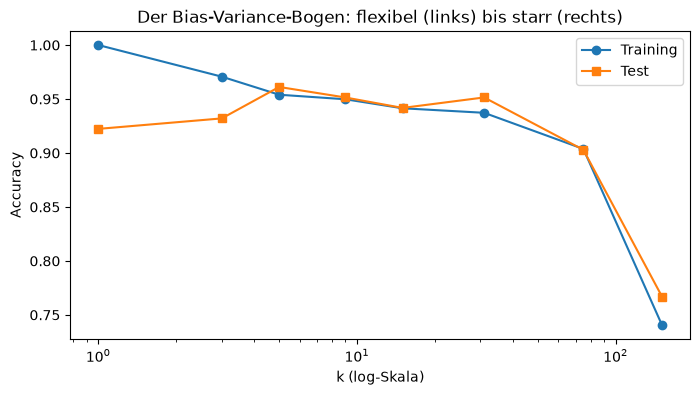

k=1:   Train 1.000 vs. Test 0.922  <- Overfitting-Luecke
k=151: Train 0.741 vs. Test 0.767 <- beide schlecht: Underfitting


In [5]:
ks = [1, 3, 5, 9, 15, 31, 75, 151]
train_acc, test_acc = [], []
for k in ks:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    train_acc.append(m.score(X_train_s, y_train))
    test_acc.append(m.score(X_test_s, y_test))

plt.figure(figsize=(8, 4))
plt.plot(ks, train_acc, marker="o", label="Training")
plt.plot(ks, test_acc, marker="s", label="Test")
plt.xscale("log"); plt.xlabel("k (log-Skala)"); plt.ylabel("Accuracy")
plt.title("Der Bias-Variance-Bogen: flexibel (links) bis starr (rechts)")
plt.legend(); plt.show()

print(f"k=1:   Train {train_acc[0]:.3f} vs. Test {test_acc[0]:.3f}  <- Overfitting-Luecke")
print(f"k=151: Train {train_acc[-1]:.3f} vs. Test {test_acc[-1]:.3f} <- beide schlecht: Underfitting")

**Lies den Plot mit Skript 1.3:**

- **Links (k=1):** Training 100 %, Test ~92 % — die Luecke ist Varianz: Das Modell
  merkt sich jeden Trainingspunkt samt Rauschen (**Overfitting**).
- **Mitte (k≈5-31):** Testleistung am besten (~95-96 %) — der Sweet Spot.
- **Rechts (k=151):** Bei 239 Trainingspunkten stimmen fast alle Nachbarn ab —
  das Modell wird zur Konstanten, Training UND Test stuerzen ab (**Underfitting/Bias**).

Beachte auch: Die Trainingskurve faellt monoton — auf Trainingsdaten gewinnt
IMMER das flexibelste Modell. Genau deshalb waehlt man k nie auf den Trainingsdaten.

## 6. Entscheidungsgrenzen sehen (fertig vorgegeben)

Zum Abschluss die Entscheidungsgrenzen fuer k=1 und k=31 — Overfitting und
Glaettung direkt im Bild.

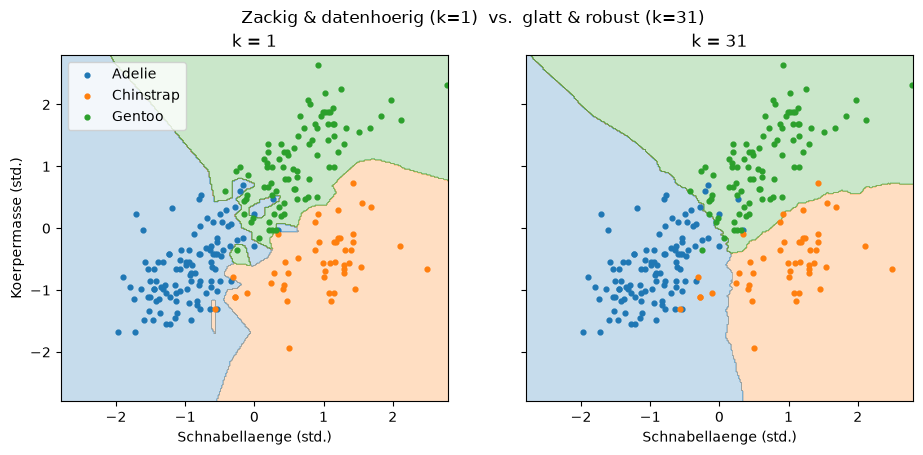

In [6]:
from matplotlib.colors import ListedColormap

def zeichne_grenze(k, achse):
    xx, yy = np.meshgrid(np.linspace(-2.8, 2.8, 300), np.linspace(-2.8, 2.8, 300))
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    klassen = np.array(["Adelie", "Chinstrap", "Gentoo"])
    Z = np.searchsorted(klassen, m.predict(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)
    achse.contourf(xx, yy, Z, alpha=0.25, cmap=ListedColormap(["C0", "C1", "C2"]))
    for i, art in enumerate(klassen):
        p = X_train_s[y_train == art]
        achse.scatter(p[:, 0], p[:, 1], s=12, color=f"C{i}", label=art)
    achse.set_title(f"k = {k}"); achse.set_xlabel("Schnabellaenge (std.)")

fig, achsen = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
zeichne_grenze(1, achsen[0]); zeichne_grenze(31, achsen[1])
achsen[0].set_ylabel("Koerpermasse (std.)"); achsen[0].legend()
plt.suptitle("Zackig & datenhoerig (k=1)  vs.  glatt & robust (k=31)")
plt.show()

## Geschafft — was du jetzt kannst

- kNN vollstaendig selbst implementieren (Distanz, Nachbarn, Votum)
- erklaeren UND zeigen, warum Distanzverfahren Skalierung brauchen (78 → 96 %)
- den Bias-Variance-Tradeoff an einer echten Kurve ablesen
- Entscheidungsgrenzen als Bild von Modellkomplexitaet lesen

**Bonusaufgaben:**
1. Nimm alle 4 numerischen Features statt 2 — wird es besser? (Und warum kann man
   die Grenze dann nicht mehr plotten?)
2. Ersetze das Mehrheitsvotum durch **gewichtete** Stimmen (Gewicht 1/Distanz).
   sklearn: `weights="distance"` — vergleiche.
3. Miss die Vorhersagezeit deines Hand-kNN fuer alle Testpunkte (`%timeit`).
   Warum ist kNN bei der VORHERSAGE langsam, waehrend andere Modelle beim
   TRAINING langsam sind?